# Build a model to predict whether a tumor is malignant or benign using the Breast Cancer dataset.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.feature_selection import (
    chi2,
    mutual_info_classif,
    SequentialFeatureSelector,
    RFE
)

In [6]:
# Load dataset

data = load_breast_cancer(as_frame=True)

X = data.data
y = data.target

print(X.shape)
X.head()

(569, 30)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## All 30 features are numeric. These are continuous biomedical measurements extracted from images.
## Target is binary categorical (0/1)

In [4]:
y.head()
##  Target Value = 0 --> Cancer Positive (Malignant)
##  Target Value = 1 --> Cancer Negative (Benign)

,target
0,0
1,0
2,0
3,0
4,0


# This dataset:

1. Already contains engineered numerical features

2. Dimensionality is only 30 features

3. So feature extraction is not necessary here.

#

## Is Feature Construction like ratios, polynomial features, interaction terms Possible here?

1. Technically yes, but not very meaningful here.
2. This dataset already contains mean, standard error, worst values.
3. So the features are already scientifically engineered.

#

## This dataset is excellent for Feature Selection since:
1. Many correlated features (radius_mean, perimeter_mean, area_mean)
2. Some features are more predictive than others
3. Dataset size is moderate

### Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

### Baseline Model (All Features)

In [9]:
model = LogisticRegression(max_iter=5000)

baseline_score = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy'
).mean()

print("Baseline CV Accuracy:", baseline_score)

Baseline CV Accuracy: 0.9516483516483516


### Explore Feature Correlations (Why Feature Selection?)

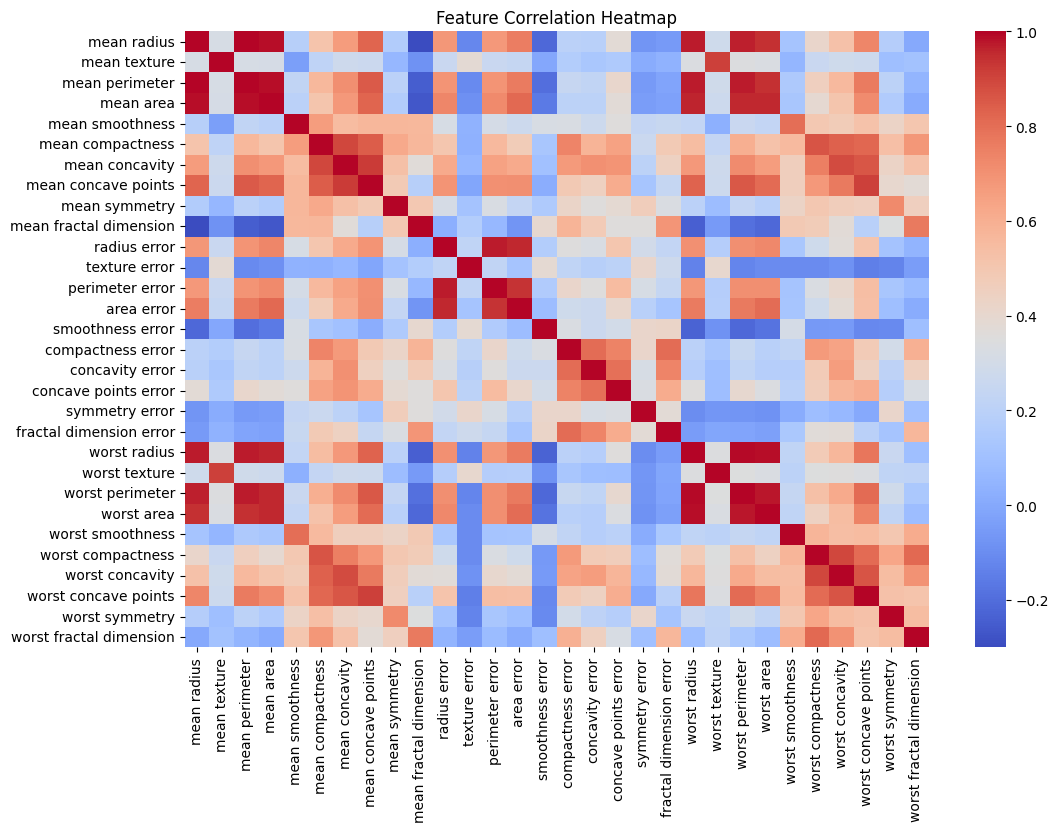

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(X_train.corr(), cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()

#### Many features are highly correlated
#### Redundant information exists

## FILTER METHOD — Correlation with Target

- When Pearson correlation is applied between a continuous variable and a binary variable, it becomes Point-Biserial Correlation, which is mathematically equivalent to Pearson correlation. So this is statistically valid.

In [11]:
corr = X_train.apply(lambda col: col.corr(y_train))  # Pearson correlation by default.

corr_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Correlation": corr
})

corr_df["AbsCorrelation"] = corr_df["Correlation"].abs()

corr_df = corr_df.sort_values(by="AbsCorrelation", ascending=False)

corr_df.head(10)

,Feature,Correlation,AbsCorrelation
worst concave points,worst concave points,-0.798176,0.798176
worst perimeter,worst perimeter,-0.783376,0.783376
mean concave points,mean concave points,-0.779907,0.779907
worst radius,worst radius,-0.776390,0.776390
mean perimeter,mean perimeter,-0.745132,0.745132
worst area,worst area,-0.737965,0.737965
mean radius,mean radius,-0.732224,0.732224
mean area,mean area,-0.713409,0.713409
mean concavity,mean concavity,-0.692052,0.692052
worst concavity,worst concavity,-0.668368,0.668368


In [12]:
# Instead of training with all 30 features, the model will now use only the selected 10 features.
top_corr_features = corr_df["Feature"].head(10).values

X_train_corr = X_train[top_corr_features]

In [13]:
X_train_corr

,worst concave points,worst perimeter,mean concave points,worst radius,mean perimeter,worst area,mean radius,mean area,mean concavity,worst concavity
546,0.02381,71.12,0.005495,11.25,65.31,384.9,10.32,324.9,0.01012,0.04384
432,0.21730,146.00,0.125900,22.03,133.80,1479.0,20.18,1250.0,0.21330,0.53080
174,0.00000,73.20,0.000000,11.54,67.49,408.3,10.66,349.6,0.00000,0.00000
221,0.09090,101.10,0.044510,14.98,88.59,686.6,13.56,561.3,0.07860,0.25770
289,0.06203,79.29,0.021730,12.36,72.17,459.3,11.37,396.0,0.02399,0.07529
...,...,...,...,...,...,...,...,...,...,...
184,0.12260,113.80,0.032630,17.80,98.92,973.1,15.28,710.6,0.05375,0.36300
300,0.19800,171.10,0.106200,25.93,129.50,2053.0,19.53,1217.0,0.21970,0.61210
509,0.21630,117.70,0.085200,17.11,103.80,909.4,15.46,731.3,0.20300,0.59110
230,0.25430,133.50,0.109000,19.59,113.40,1189.0,17.05,895.0,0.19100,0.50180


### FILTER METHOD — Chi-Square
As Chi-Square needs Categorical data, let us not use it here. (But, it can be used if the numeric features are first converted as categorical).

## FILTER METHOD — Mutual Information
Suitable fo this data set.
- Works with continuous features
- Works with categorical targets
- Detects nonlinear relationships
- Does not assume linearity

In [14]:
mi_scores = mutual_info_classif(X_train, y_train)

mi_df = pd.DataFrame({
    "Feature": X_train.columns,
    "MI": mi_scores
})

mi_df = mi_df.sort_values(by="MI", ascending=False)

mi_df.head(10)

,Feature,MI
22,worst perimeter,0.469648
20,worst radius,0.461472
23,worst area,0.460975
7,mean concave points,0.443172
27,worst concave points,0.442278
2,mean perimeter,0.415626
0,mean radius,0.361534
3,mean area,0.360737
6,mean concavity,0.353457
13,area error,0.338685


## FILTER METHOD — Fisher Score
Suitable fo this data set.

Target = binary class

Features = continuous measurements

In [15]:
def fisher_score(X, y):

    scores = []

    for col in X.columns:

        feature = X[col]

        classes = y.unique()

        overall_mean = feature.mean()

        numerator = 0
        denominator = 0

        for c in classes:

            class_feature = feature[y == c]

            class_mean = class_feature.mean()
            class_var = class_feature.var()

            n = len(class_feature)

            numerator += n * (class_mean - overall_mean)**2
            denominator += n * class_var

        score = numerator / denominator
        scores.append(score)

    return pd.Series(scores, index=X.columns)


fisher_scores = fisher_score(X_train, y_train)

fisher_df = fisher_scores.sort_values(ascending=False)

fisher_df.head(10)

,0
worst concave points,1.747103
worst perimeter,1.580179
mean concave points,1.544468
worst radius,1.509555
mean perimeter,1.241943
worst area,1.189140
mean radius,1.150022
mean area,1.030828
mean concavity,0.914566
worst concavity,0.803572


## WRAPPER METHOD — Sequential Forward Selection

In [16]:
model = LogisticRegression(max_iter=5000)

sfs = SequentialFeatureSelector(
                                  model,
                                  n_features_to_select=10,     ## Selecting best 10 features
                                  direction='forward',
                                  scoring='accuracy',
                                  cv=5
                               )

sfs.fit(X_train, y_train)

selected_features_sfs = X_train.columns[sfs.get_support()]

print("Selected Features (SFS):")
print(selected_features_sfs)

Selected Features (SFS):
Index(['mean radius', 'mean texture', 'mean area', 'mean smoothness',
       'mean compactness', 'mean concavity', 'worst radius', 'worst texture',
       'worst perimeter', 'worst compactness'],
      dtype='object')


## WRAPPER METHOD — RFE

In [17]:
model = LogisticRegression(max_iter=5000)

rfe = RFE(model, n_features_to_select=10)

rfe.fit(X_train, y_train)

selected_features_rfe = X_train.columns[rfe.support_]

print("Selected Features (RFE):")
print(selected_features_rfe)

Selected Features (RFE):
Index(['mean radius', 'mean concavity', 'texture error', 'perimeter error',
       'worst radius', 'worst smoothness', 'worst compactness',
       'worst concavity', 'worst concave points', 'worst symmetry'],
      dtype='object')


## EMBEDDED METHOD — Random Forest Importance

In [18]:
rf = RandomForestClassifier(random_state=42)

rf.fit(X_train, y_train)

importances = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
)

importances = importances.sort_values(ascending=False)

importances.head(10)

,0
worst area,0.140016
worst concave points,0.129530
worst radius,0.097696
mean concave points,0.090885
worst perimeter,0.072226
mean perimeter,0.069574
mean radius,0.068676
mean concavity,0.057638
mean area,0.049172
worst concavity,0.034340


## Compare Feature Rankings

In [19]:
comparison_df = pd.DataFrame({
    "Correlation": corr.abs(),
    "MutualInfo": mi_scores,
    "FisherScore": fisher_scores,
    "RFImportance": rf.feature_importances_
}, index=X_train.columns)

comparison_df.sort_values(by="RFImportance", ascending=False).head(10)

,Correlation,MutualInfo,FisherScore,RFImportance
worst area,0.737965,0.460975,1.189140,0.140016
worst concave points,0.798176,0.442278,1.747103,0.129530
worst radius,0.776390,0.461472,1.509555,0.097696
mean concave points,0.779907,0.443172,1.544468,0.090885
worst perimeter,0.783376,0.469648,1.580179,0.072226
mean perimeter,0.745132,0.415626,1.241943,0.069574
mean radius,0.732224,0.361534,1.150022,0.068676
mean concavity,0.692052,0.353457,0.914566,0.057638
mean area,0.713409,0.360737,1.030828,0.049172
worst concavity,0.668368,0.318703,0.803572,0.034340


## Train Final Model Using Selected Features

Example using SFS features.

In [21]:
X_train_sfs = X_train[selected_features_sfs]

final_model = LogisticRegression(max_iter=5000)

final_score = cross_val_score(
    final_model,
    X_train_sfs,
    y_train,
    cv=5,
    scoring='accuracy'
).mean()

print("CV Accuracy using selected features:", final_score)

CV Accuracy using selected features: 96.04395604395603


In [23]:
print("Baseline Accuracy:", baseline_score*100)
print("Feature Selected Accuracy:", final_score*100)

Baseline Accuracy: 95.16483516483515
Feature Selected Accuracy: 96.04395604395603


# Commonly used real-world feature selection pipeline.

1. Data Understanding & Cleaning
   Before formal feature selection:

       - Remove IDs or leakage variables (e.g., patient ID, future information).

       - Handle missing values.

       - Standardize or normalize features if needed.

       - Use domain knowledge to keep essential variables.
            - Original features: 300, After basic cleaning: 280

2. Remove Constant / Near-Constant Features:

       - Features with almost no variance carry  little information.

       - Example rule:Variance below a threshold (e.g., <0.01).

       - 280 → 260 features

3. Check Multi-colinearity and Remove Highly Correlated Features (Redundancy Check)

      - To avoid redundancy in input features, Compute a feature–feature correlation matrix and drop one feature from pairs with very high correlation (e.g., |r| > 0.9).

      - 260 → 150 features

4. Filter-Based Screening (fast and model-independent):

      - Keep the top-k features or those above a threshold.

      - 150 → 50 features

5. Wrapper-Based Refinement:

      - Now run a wrapper method on the reduced feature set
      - 50 → 10–20 features

6. Embedded Methods (Model Confirmation):

      - Provide built-in feature importance
      - Confirm whether selected features are consistently important.

7. Model Evaluation:
   
      - Train the final model with the selected features and compare against the baseline

8. Stability Check (Optional but Useful):
      - Check whether the same features appear across different cross-validation folds.

         - High stability → more reliable features.